# Logistic Regression, LDA, and QDA on the Digits Dataset

**Name:** Mahesh Janaranjana
**Index No:** 20260064
**Programme:** MSc in Applied Artificial Intelligence (IIT)
**Module assignment:** Logistic Regression, LDA, and QDA

---

In this notebook I work through the comparison of Linear Discriminant Analysis (LDA)
and Quadratic Discriminant Analysis (QDA) on the `load_digits` dataset, and I also add a
logistic regression baseline. My main aim is to understand how the assumption that the
classes share one covariance matrix (the LDA assumption) actually holds up on real data,
and what that means for which classifier I should pick.

I have organised the notebook to follow the six tasks in the assignment brief.

## Setup

First I import everything I need. I fix a single random seed so the results are
reproducible every time the notebook is run.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# one seed used everywhere so the split / models are repeatable
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# QDA complains about collinear / rank-deficient pixels on this dataset; I deal
# with that properly in Task 2 with regularisation. This filter just keeps any
# leftover warning text out of the way.
warnings.filterwarnings("ignore", message="Variables are collinear")

print("Libraries loaded.")

Libraries loaded.


## Task 1 - Data Preparation

The digits dataset has 1797 samples, each one an 8x8 grayscale image of a handwritten
digit flattened into 64 features (pixel intensities 0-16). There are 10 classes (0-9).

Below I load the data, print its shape, and show ten example images so it is clear what
we are actually classifying.

Feature matrix shape: (1797, 64)
Target vector shape : (1797,)
Classes present     : [0 1 2 3 4 5 6 7 8 9]


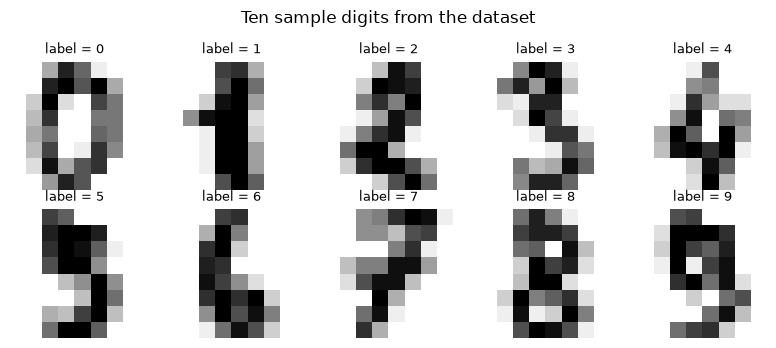

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)
print("Classes present     :", np.unique(y))

# show a few real digit images so the data is not just an abstract matrix
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"label = {label}", fontsize=9)
    ax.axis("off")
fig.suptitle("Ten sample digits from the dataset", fontsize=12)
plt.tight_layout()
plt.show()

Next I standardise every feature so each pixel has zero mean and unit variance.
I fit the scaler on the **training** part only and then apply it to the test part. I did
it this way (rather than scaling the whole dataset first) so that no information from the
test set leaks into the training process - that keeps the test accuracy honest.

Some corner pixels are almost always zero, so they have (near) zero variance;
`StandardScaler` handles those safely without producing NaNs, it just leaves them flat.

Finally I split the data 70% train / 30% test, and I stratify on the labels so each
digit is represented in the same proportion in both sets.

In [4]:
# split first, then fit the scaler on the training data only (avoids leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

Training set: (1257, 64)
Test set    : (540, 64)
Train class counts: [124 127 124 128 127 127 127 125 122 126]
Test  class counts: [54 55 53 55 54 55 54 54 52 54]


## Task 2 - Model Training

Now I train LDA and QDA on the full 64-dimensional standardised data and compare their
test accuracy.

The key difference between them:
- **LDA** assumes every class shares one common covariance matrix.
- **QDA** estimates a separate covariance matrix for each class.

LDA fits without any trouble. QDA is a different story: when I tried to fit it on the raw
64 pixels with default settings, it failed outright with a `LinAlgError` saying the
covariance matrix of a class "is not full rank". That happens because QDA estimates a
separate covariance matrix **per class** and then has to invert it - but several pixels
(for example the always-blank corner pixels) carry no variation inside a class, so that
class's covariance matrix is rank-deficient and cannot be inverted. LDA sidesteps this
because it pools every class into one shared covariance estimate, which is far better
conditioned.

The fix is `reg_param`, which shrinks each class covariance towards a diagonal form and
makes it invertible again. So below I fit LDA normally, and I fit QDA with a small
`reg_param`.

In [5]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_acc = accuracy_score(y_test, lda.predict(X_test))
print(f"LDA test accuracy (64-D): {lda_acc:.4f}")

# QDA needs regularisation here, otherwise the rank-deficient class covariances
# make it error out. reg_param shrinks each covariance towards diagonal.
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda.fit(X_train, y_train)
qda_acc = accuracy_score(y_test, qda.predict(X_test))
print(f"QDA test accuracy (64-D, reg_param=0.1): {qda_acc:.4f}")

LDA test accuracy (64-D): 0.9519
QDA test accuracy (64-D, reg_param=0.1): 0.9722


To check how sensitive QDA is to that regularisation, I sweep a few values of
`reg_param`. Too little and it is still nearly singular; a moderate amount works best.

In [6]:
print("Effect of reg_param on QDA (64-D):")
for rp in [0.001, 0.01, 0.1, 0.5]:
    m = QuadraticDiscriminantAnalysis(reg_param=rp).fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"  reg_param = {rp:<6} -> test accuracy = {acc:.4f}")

Effect of reg_param on QDA (64-D):
  reg_param = 0.001  -> test accuracy = 0.9500
  reg_param = 0.01   -> test accuracy = 0.9648
  reg_param = 0.1    -> test accuracy = 0.9722
  reg_param = 0.5    -> test accuracy = 0.9704


## Task 3 - Covariance Analysis

Here I want to look directly at the covariance assumption. I project the standardised
data down to 2 dimensions with PCA, then estimate a separate covariance matrix for each
class in that 2-D space and compare them.

The brief frames the LDA assumption as $\Sigma_1 = \Sigma_2$, so I print the covariance
matrices for two classes side by side, and then I summarise all ten classes numerically
to see how much they really vary.

In [7]:
# fit PCA on the training data and project both splits to 2 components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print("Variance explained by the 2 components:",
      np.round(pca.explained_variance_ratio_, 3),
      " (total =", round(pca.explained_variance_ratio_.sum(), 3), ")")

# use all the 2-D points we have for the covariance analysis
X_2d_all = np.vstack([X_train_2d, X_test_2d])
y_2d_all = np.concatenate([y_train, y_test])

cov_by_class = {c: np.cov(X_2d_all[y_2d_all == c], rowvar=False)
                for c in np.unique(y_2d_all)}

print("\nCovariance matrix for class 1 (Sigma_1):\n", np.round(cov_by_class[1], 3))
print("\nCovariance matrix for class 2 (Sigma_2):\n", np.round(cov_by_class[2], 3))

diff = cov_by_class[1] - cov_by_class[2]
print("\nFrobenius norm of (Sigma_1 - Sigma_2):", round(np.linalg.norm(diff), 3))

Variance explained by the 2 components: [0.121 0.098]  (total = 0.22 )

Covariance matrix for class 1 (Sigma_1):
 [[ 2.553 -2.02 ]
 [-2.02   2.932]]

Covariance matrix for class 2 (Sigma_2):
 [[ 4.016 -0.922]
 [-0.922  1.28 ]]

Frobenius norm of (Sigma_1 - Sigma_2): 2.698


To go beyond just two classes, I build a small table describing each class's
2-D covariance: the variance along PC1 and PC2, the off-diagonal covariance, and the
determinant (which roughly measures the "spread/area" of that class's ellipse). If LDA's
single-covariance assumption were reasonable, these rows would all look very similar.

In [8]:
rows = []
for c, cov in cov_by_class.items():
    rows.append({
        "class": c,
        "var_PC1": cov[0, 0],
        "var_PC2": cov[1, 1],
        "cov_PC1_PC2": cov[0, 1],
        "determinant": np.linalg.det(cov),
    })

cov_table = pd.DataFrame(rows).set_index("class").round(2)
cov_table

,var_PC1,var_PC2,cov_PC1_PC2,determinant
class,,,,
0,0.68,1.05,-0.20,0.67
1,2.55,2.93,-2.02,3.40
2,4.02,1.28,-0.92,4.29
3,1.45,3.28,-0.12,4.75
4,2.62,2.31,0.18,6.03
5,2.79,2.43,0.75,6.20
6,0.35,0.95,-0.31,0.24
7,3.49,2.85,-1.96,6.07
8,1.80,1.31,-0.21,2.31


**Is $\Sigma_1 = \Sigma_2$ reasonable here?**

Not really. Looking at the two printed matrices, the Frobenius norm of their difference
is clearly non-zero, and in the summary table the per-class variances and determinants
are quite different from one digit to the next - some classes form tight clusters and
others are much more spread out, with different orientations. So the classes do **not**
share a common covariance structure.

Strictly speaking this means the LDA equal-covariance assumption is violated, which on
the face of it argues for QDA. I keep this in mind, but I will check it against the
actual accuracies later rather than just trusting the assumption.

## Task 4 - Decision Boundary Visualisation

Now I train LDA and QDA on the 2-D PCA representation and draw their decision regions.
Working in 2-D is the only way to actually *see* the boundaries. I reuse the projection
from Task 3 (`X_train_2d` / `X_test_2d`).

I expect the shapes to differ: LDA should give straight-line boundaries between classes,
while QDA should give curved ones.

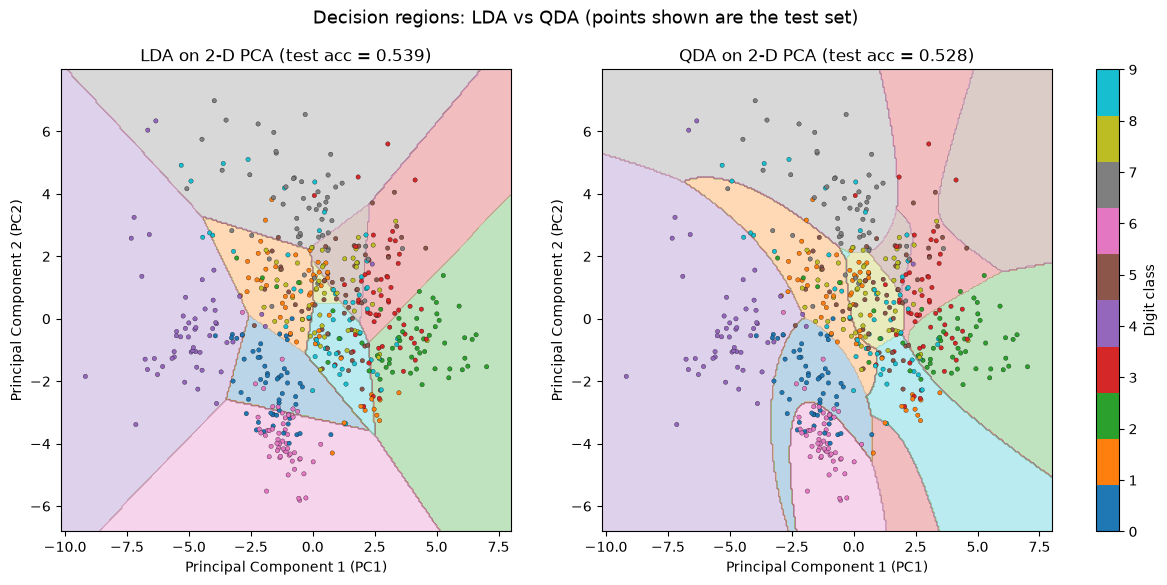

LDA (2-D) test accuracy: 0.5389
QDA (2-D) test accuracy: 0.5278


In [9]:
def plot_decision_regions(model, X2d, y_true, title, ax):
    """Fill the background with the model's predicted class and overlay the points."""
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="tab10",
                levels=np.arange(-0.5, 10.5, 1))
    scatter = ax.scatter(X2d[:, 0], X2d[:, 1], c=y_true, cmap="tab10",
                         s=10, edgecolor="k", linewidth=0.2)
    ax.set_xlabel("Principal Component 1 (PC1)")
    ax.set_ylabel("Principal Component 2 (PC2)")
    ax.set_title(title)
    return scatter


# train both models on the 2-D data
lda_2d = LinearDiscriminantAnalysis().fit(X_train_2d, y_train)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_train_2d, y_train)

lda_2d_acc = accuracy_score(y_test, lda_2d.predict(X_test_2d))
qda_2d_acc = accuracy_score(y_test, qda_2d.predict(X_test_2d))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_regions(lda_2d, X_test_2d, y_test,
                      f"LDA on 2-D PCA (test acc = {lda_2d_acc:.3f})", axes[0])
sc = plot_decision_regions(qda_2d, X_test_2d, y_test,
                          f"QDA on 2-D PCA (test acc = {qda_2d_acc:.3f})", axes[1])

cbar = fig.colorbar(sc, ax=axes, ticks=range(10), fraction=0.046, pad=0.04)
cbar.set_label("Digit class")
fig.suptitle("Decision regions: LDA vs QDA (points shown are the test set)", fontsize=13)
plt.show()

print(f"LDA (2-D) test accuracy: {lda_2d_acc:.4f}")
print(f"QDA (2-D) test accuracy: {qda_2d_acc:.4f}")

As expected, the LDA plot is carved up by straight lines, while the QDA plot has
curved, roughly elliptical regions that wrap around the denser clusters. The accuracies
here are much lower than in Task 2 - that is not a mistake, it is because squeezing 64
pixels into just 2 principal components throws away most of the information (see the
explained-variance number printed in Task 3). Ten digits simply overlap a lot in 2-D.

## Task 5 - Logistic Regression

For comparison I also fit a multinomial logistic regression on the same 2-D PCA data and
plot its decision boundary. Logistic regression is a linear classifier, so I expect
straight boundaries similar in spirit to LDA.

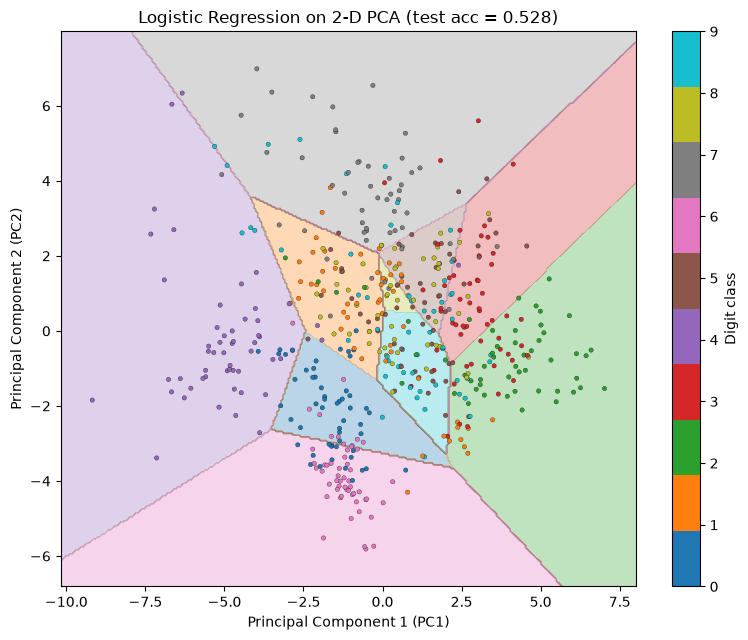

Logistic Regression (2-D) test accuracy: 0.5278


In [10]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_2d, y_train)
logreg_acc = accuracy_score(y_test, logreg.predict(X_test_2d))

fig, ax = plt.subplots(figsize=(8, 6.5))
sc = plot_decision_regions(logreg, X_test_2d, y_test,
                          f"Logistic Regression on 2-D PCA (test acc = {logreg_acc:.3f})",
                          ax)
cbar = fig.colorbar(sc, ax=ax, ticks=range(10))
cbar.set_label("Digit class")
plt.tight_layout()
plt.show()

print(f"Logistic Regression (2-D) test accuracy: {logreg_acc:.4f}")

The logistic regression boundaries are straight, like LDA's, and its 2-D accuracy
lands in the same ballpark. That makes sense - both are linear models, they just estimate
the boundary in different ways (LDA models each class's distribution, logistic regression
models the class probability directly).

## Task 6 - Theoretical Analysis

**Discriminant function.** For each class $k$, with class mean $\mu_k$, covariance
$\Sigma_k$, and prior $\pi_k$, the discriminant function is

$$\delta_k(x) = -\tfrac{1}{2}\log|\Sigma_k| - \tfrac{1}{2}(x-\mu_k)^T \Sigma_k^{-1}(x-\mu_k) + \log \pi_k .$$

A point $x$ is assigned to whichever class gives the largest $\delta_k(x)$.

**Why LDA gives linear boundaries.** LDA assumes all classes share one covariance,
$\Sigma_k = \Sigma$ for every $k$. If I expand the quadratic term,

$$(x-\mu_k)^T \Sigma^{-1}(x-\mu_k) = x^T\Sigma^{-1}x - 2\mu_k^T\Sigma^{-1}x + \mu_k^T\Sigma^{-1}\mu_k ,$$

the $x^T\Sigma^{-1}x$ part and the $\log|\Sigma|$ part are **the same for every class**, so
when I compare two classes (set $\delta_i(x)=\delta_j(x)$) they cancel out. What is left
is linear in $x$, so the boundary between any two classes is a straight line / hyperplane.

**Why QDA gives quadratic boundaries.** QDA keeps a separate $\Sigma_k$ per class. Now the
$x^T\Sigma_k^{-1}x$ term and the $\log|\Sigma_k|$ term are different for each class and do
**not** cancel when comparing two classes. The leftover comparison still contains a term
quadratic in $x$, so the boundary is a curve (a conic section - ellipse, parabola, etc.).
This is exactly what showed up in the Task 4 plots.

**Which model is more appropriate for this dataset?** Based on my results, **regularised
QDA is the most accurate on the full 64-D digits problem** (about 0.97 vs 0.95 for LDA).
This actually agrees with Task 3: I showed there that the classes clearly do *not* share a
single covariance matrix, so a model that allows a separate covariance per class (QDA) has
the freedom to fit each digit's shape, and that extra flexibility pays off here.

The important caveat is that QDA only works once it is regularised. With default settings
it failed completely, because estimating a full covariance per class from correlated /
constant pixels gives rank-deficient, non-invertible matrices (the issue from Task 2).
`reg_param` shrinks those covariances towards diagonal and makes the problem well-posed
again, after which QDA edges ahead of LDA.

So my overall reading: LDA is the safer, simpler baseline and is already very good
(~0.95) with no tuning, but for this dataset QDA is theoretically better motivated (unequal
covariances) and, once regularised, also empirically better. I would report LDA as the
robust default and regularised QDA as the higher-accuracy choice.

## Summary - what I found

Putting all the numbers in one place:

In [11]:
summary = pd.DataFrame({
    "Model": [
        "LDA (64-D, full features)",
        "QDA (64-D, reg_param=0.1)",
        "LDA (2-D PCA)",
        "QDA (2-D PCA)",
        "Logistic Regression (2-D PCA)",
    ],
    "Test accuracy": [
        lda_acc, qda_acc, lda_2d_acc, qda_2d_acc, logreg_acc,
    ],
})
summary["Test accuracy"] = summary["Test accuracy"].round(4)
summary

,Model,Test accuracy
0,"LDA (64-D, full features)",0.9519
1,"QDA (64-D, reg_param=0.1)",0.9722
2,LDA (2-D PCA),0.5389
3,QDA (2-D PCA),0.5278
4,Logistic Regression (2-D PCA),0.5278


**My takeaways:**

1. On the full 64-D data, regularised QDA gave the best accuracy (~0.97), slightly ahead
   of LDA (~0.95). This lines up with the covariance analysis - because the classes really
   do have different covariances, QDA's per-class flexibility helps.
2. The catch is that QDA does not work out of the box here: it has to be regularised,
   otherwise the rank-deficient per-class covariances make it fail. LDA needs no tuning and
   is already strong, so it is the more robust default even if it is marginally less
   accurate.
3. The 2-D PCA models all scored much lower (~0.53), simply because 2 components keep only
   about 22% of the variance. They were useful for *seeing* the linear (LDA, logistic) vs
   quadratic (QDA) boundaries, not for getting the best accuracy.

Overall: I would treat **LDA as the safe, no-tuning baseline** and **regularised QDA as the
best-accuracy model** for this dataset.